#Practical 01

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

# ==============================
# LOAD & PREPROCESS DATA
# ==============================
df = pd.read_csv("/content/DESCRIPTIVE_STATISTICS.csv")

cols = ['Price', 'Age at time of purchase', 'Area (ft.)']
df = df.copy()

# Convert Age column to numeric and fill missing values
df['Age at time of purchase'] = pd.to_numeric(df['Age at time of purchase'], errors='coerce')
df['Age at time of purchase'].fillna(df['Age at time of purchase'].median(), inplace=True)

# ==============================
# 1. UNIVARIATE ANALYSIS (NUMERICAL)
# ==============================
print("\n--- Univariate Numerical ---")
print(df[cols].describe())

stats = df[cols].agg(['mean', 'median'])
stats.loc['mode'] = df[cols].mode().iloc[0]
print(stats.T)

# ==============================
# 2. UNIVARIATE ANALYSIS (CATEGORICAL)
# ==============================
print("\n--- Deal Satisfaction ---")
deal_sat = df['Deal satisfaction'].value_counts().to_frame('Frequency')
deal_sat['Percentage (%)'] = (deal_sat['Frequency'] / len(df)) * 100
print(deal_sat.round(2))

# ==============================
# 3. NUMERICAL - NUMERICAL
# ==============================
print("\n--- Correlation (Price vs Area) ---")
corr = df[['Price', 'Area (ft.)']].corr()
print(corr.round(3))

# ==============================
# 4. CATEGORICAL - NUMERICAL
# ==============================
print("\n--- Gender vs Age ---")
gender_age = df.groupby('Gender')['Age at time of purchase'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).round(2)
print(gender_age)

# ==============================
# 5. CATEGORICAL - CATEGORICAL
# ==============================
print("\n--- Gender vs Property Type (Counts) ---")
ct = pd.crosstab(df['Gender'], df['Type of property'])
print(ct)

print("\n--- Gender vs Property Type (%) ---")
ct_pct = pd.crosstab(df['Gender'], df['Type of property'], normalize='index') * 100
print(ct_pct.round(2))


--- Univariate Numerical ---
               Price  Age at time of purchase   Area (ft.)
count      20.000000                 20.00000    20.000000
mean   244250.000000                 30.50000  1550.000000
std     43687.737651                  5.44349   336.389499
min    175000.000000                 22.00000  1050.000000
25%    208750.000000                 26.75000  1287.500000
50%    245000.000000                 30.00000  1525.000000
75%    276250.000000                 34.25000  1762.500000
max    320000.000000                 42.00000  2200.000000
                             mean    median      mode
Price                    244250.0  245000.0  175000.0
Age at time of purchase      30.5      30.0      28.0
Area (ft.)                 1550.0    1525.0    1050.0

--- Deal Satisfaction ---
                   Frequency  Percentage (%)
Deal satisfaction                           
5                          8            40.0
4                          7            35.0
3               

/tmp/ipykernel_1716/2050672514.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age at time of purchase'].fillna(df['Age at time of purchase'].median(), inplace=True)


#Practical 02

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Load data
df = pd.read_csv("HYPOTHESIS_TESTING.csv")

# Clean gender column
df['Gender'] = df['Gender'].str.lower()

# Function for t-test
def run_ttest(data, label):
    male = data[data['Gender'] == 'male']['Salary']
    female = data[data['Gender'] == 'female']['Salary']

    t_value, _ = ttest_ind(male, female, equal_var=False)

    tabulated_t = 1.96  # approx for large sample

    print(f"\n--- {label} ---")
    print("t-value:", round(t_value, 4))
    print("tabulated t-value:", tabulated_t)

    if abs(t_value) < tabulated_t:
        print("Inference: No significant gender difference (Fail to reject H0)")
    else:
        print("Inference: Significant gender difference (Reject H0)")

# Full dataset
run_ttest(df, "Overall Dataset")

# Above 35
run_ttest(df[df['Age'] > 35], "Age > 35")

# Below 35
run_ttest(df[df['Age'] <= 35], "Age ≤ 35")


--- Overall Dataset ---
t-value: -0.1562
tabulated t-value: 1.96
Inference: No significant gender difference (Fail to reject H0)

--- Age > 35 ---
t-value: 0.1637
tabulated t-value: 1.96
Inference: No significant gender difference (Fail to reject H0)

--- Age ≤ 35 ---
t-value: 0.2009
tabulated t-value: 1.96
Inference: No significant gender difference (Fail to reject H0)


#Practical 03

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("student_data_cleaning.csv")
df['StudyHours_target'] = (df['StudyHours'] > 3).astype(int)

X = df[['Age', 'Math', 'Science', 'Attendance']]
y = df['StudyHours_target']

# =========================
# BEFORE CLEANING
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline_raw = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline_raw.fit(X_train, y_train)
r2_before = r2_score(y_test, pipeline_raw.predict_proba(X_test)[:, 1])

print("R2 BEFORE CLEANING:", r2_before)

# =========================
# DATA CLEANING
# =========================
df_clean = df.copy()
num_cols = ['Age', 'Math', 'Science', 'Attendance']

# Missing value imputation
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Outlier treatment (IQR clipping)
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = np.clip(df_clean[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# =========================
# AFTER CLEANING
# =========================
X_clean = df_clean[num_cols]
y_clean = df_clean['StudyHours_target']

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42
)

pipeline_clean = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline_clean.fit(X_train, y_train)
r2_after = r2_score(y_test, pipeline_clean.predict_proba(X_test)[:, 1])

print("R2 AFTER CLEANING:", r2_after)

# =========================
# COMPARISON
# =========================
print("\n===== RESULT =====")
print("Before Cleaning:", r2_before)
print("After Cleaning:", r2_after)
print("Conclusion: Data cleaning improves model performance")

R2 BEFORE CLEANING: 0.6428438739786575
R2 AFTER CLEANING: 0.6766737587950098

===== RESULT =====
Before Cleaning: 0.6428438739786575
After Cleaning: 0.6766737587950098
Conclusion: Data cleaning improves model performance


#Practical 04

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Price                    20 non-null     int64 
 1   Age at time of purchase  20 non-null     int64 
 2   Area (ft.)               20 non-null     int64 
 3   Deal satisfaction        20 non-null     int64 
 4   Gender                   20 non-null     object
 5   Type of property         20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None
               Price  Age at time of purchase   Area (ft.)  Deal satisfaction
count      20.000000                 20.00000    20.000000           20.00000
mean   244250.000000                 30.50000  1550.000000            4.10000
std     43687.737651                  5.44349   336.389499            0.91191
min    175000.000000                 22.00000  1050.000000            2.00000
25%    208750.000000         

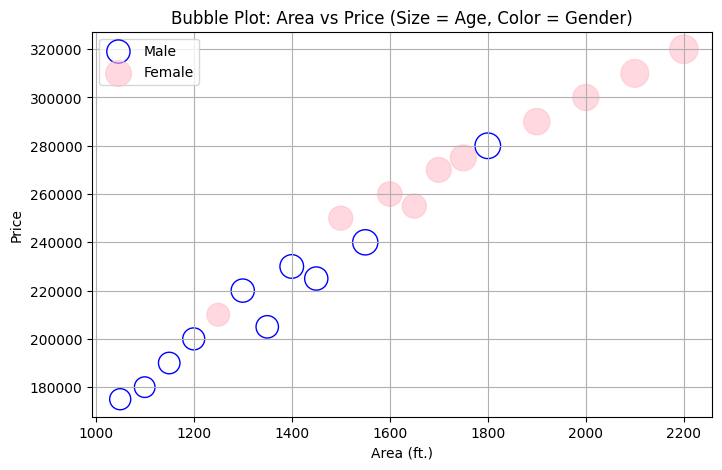

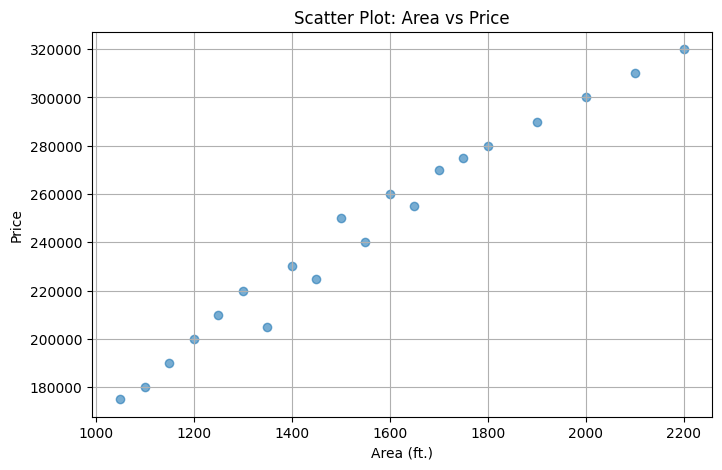

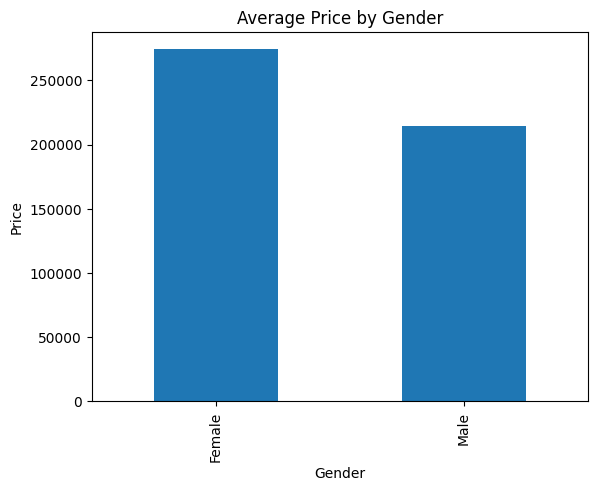

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("DESCRIPTIVE_STATISTICS.csv")
print(df.info())
print(df.describe())
# Clean Price column
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "").astype(float)

# Convert needed columns
df["Area (ft.)"] = pd.to_numeric(df["Area (ft.)"], errors="coerce")
df["Age at time of purchase"] = pd.to_numeric(df["Age at time of purchase"], errors="coerce")

# Drop missing values
data = df[["Area (ft.)", "Price", "Age at time of purchase", "Gender"]].dropna()

# Split by gender
male = data[data["Gender"] == "Male"]
female = data[data["Gender"] == "Female"]

# Plot
plt.figure(figsize=(8,5))

plt.scatter(male["Area (ft.)"], male["Price"],
            s=male["Age at time of purchase"] * 10,
            facecolors='none', edgecolors='blue',
            label="Male")

plt.scatter(female["Area (ft.)"], female["Price"],
            s=female["Age at time of purchase"] * 10,
            color='pink', alpha=0.6,
            label="Female")

plt.xlabel("Area (ft.)")
plt.ylabel("Price")
plt.title("Bubble Plot: Area vs Price (Size = Age, Color = Gender)")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(data["Area (ft.)"], data["Price"], alpha=0.6)

plt.xlabel("Area (ft.)")
plt.ylabel("Price")
plt.title("Scatter Plot: Area vs Price")
plt.grid(True)

plt.show()

avg_price = data.groupby("Gender")["Price"].mean()

avg_price.plot(kind='bar')

plt.title("Average Price by Gender")
plt.ylabel("Price")
plt.xlabel("Gender")
plt.show()

#Practical 05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, classification_report, silhouette_score

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("evaluation.csv")

# Clean numeric columns
for col in ['Price', 'Mileage', 'EngineV']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Price'])

# =========================
# COMMON PREPROCESSOR
# =========================
features = ['Brand', 'Body', 'Mileage', 'EngineV', 'Engine Type', 'Registration', 'Year']
X = df[features]
y_reg = df['Price']

num_cols = ['Mileage', 'EngineV', 'Year']
cat_cols = ['Brand', 'Body', 'Engine Type', 'Registration']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

# =========================
# REGRESSION
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

lr = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
rf = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42))])

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

def eval_reg(model, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name} -> RMSE: {rmse:.2f} | R2: {r2:.2f}")

print("\n--- Regression ---")
eval_reg(lr, "Linear Regression")
eval_reg(rf, "Random Forest")

# =========================
# CLASSIFICATION
# =========================
df['Price_Class'] = pd.cut(df['Price'],
                          bins=[0, 300000, 700000, np.inf],
                          labels=['Low', 'Medium', 'High'])

y_cls = LabelEncoder().fit_transform(df['Price_Class'])

X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

lr_clf = Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=1000))])
rf_clf = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=42))])

lr_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

def eval_cls(model, name):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)
    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_test, prob, multi_class='ovr'), 3))
    print(classification_report(y_test, pred))

print("\n--- Classification ---")
eval_cls(lr_clf, "Logistic Regression")
eval_cls(rf_clf, "Random Forest")

# =========================
# UNSUPERVISED (KMEANS)
# =========================
X_unsup = df[['Mileage', 'EngineV', 'Year']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_unsup)

score = silhouette_score(X_unsup, labels)

print("\n--- Clustering ---")
print("Silhouette Score:", round(score, 3))


--- Regression ---
Linear Regression -> RMSE: 125781.14 | R2: 0.96
Random Forest -> RMSE: 52818.30 | R2: 0.99

--- Classification ---

Logistic Regression
Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


Random Forest
Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


--- Clusteri

#Practical 06

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Performance Comparison ---
               Accuracy  Spam Precision  Spam Recall  Spam F1
Baseline       0.777778             0.0          0.0      0.0
Undersampling  1.000000             1.0          1.0      1.0
Oversampling   1.000000             1.0          1.0      1.0
SMOTE          1.000000             1.0          1.0      1.0


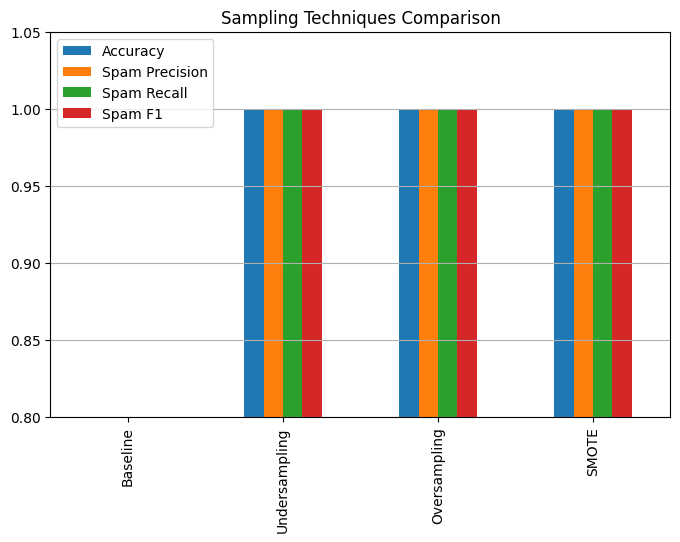


--- DBSCAN Outliers ---
Number of outliers: 2
Outlier label distribution:
label
0    1
1    1
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.cluster import DBSCAN

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("spam.csv")   # assume label column = 'label'

X = df.drop('label', axis=1)
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================
# BASELINE MODEL
# =========================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# =========================
# SAMPLING METHODS
# =========================
def train_with_sampler(sampler):
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_res, y_res)
    return m.predict(X_test)

y_pred_under = train_with_sampler(RandomUnderSampler(random_state=42))
y_pred_over = train_with_sampler(RandomOverSampler(random_state=42))
y_pred_smote = train_with_sampler(SMOTE(random_state=42))

# =========================
# EVALUATION
# =========================
results = {}

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

    results[name] = {
        'Accuracy': acc,
        'Spam Precision': precision[1],
        'Spam Recall': recall[1],
        'Spam F1': f1[1]
    }

add_result('Baseline', y_test, y_pred)
add_result('Undersampling', y_test, y_pred_under)
add_result('Oversampling', y_test, y_pred_over)
add_result('SMOTE', y_test, y_pred_smote)

df_results = pd.DataFrame(results).T
print("\n--- Performance Comparison ---")
print(df_results)

df_results.plot(kind='bar', figsize=(8,5))
plt.title("Sampling Techniques Comparison")
plt.ylim(0.8, 1.05)
plt.grid(axis='y')
plt.show()

# =========================
# DBSCAN (OUTLIER DETECTION)
# =========================
dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters = dbscan.fit_predict(X)

outliers = (clusters == -1)

print("\n--- DBSCAN Outliers ---")
print("Number of outliers:", outliers.sum())

if outliers.sum() > 0:
    print("Outlier label distribution:")
    print(df['label'][outliers].value_counts())

#Practical 07

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.feature_selection import SelectKBest, f_classif

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("feature_engg.csv")

# Target
y = df['Target']

# =========================
# BEFORE (RAW FEATURES)
# =========================
X = df.drop('Target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred_before = model.predict(X_test)
acc_before = accuracy_score(y_test, pred_before)

print("Accuracy BEFORE:", round(acc_before, 3))

# =========================
# FEATURE ENGINEERING
# =========================
df_fe = df.copy()

# Create new features
df_fe['TotalScore'] = df_fe['Math'] + df_fe['Science']
df_fe['Efficiency'] = df_fe['StudyHours'] / (df_fe['Attendance'] + 1)

# =========================
# FEATURE SELECTION
# =========================
X_fe = df_fe.drop('Target', axis=1)

selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_fe, y)

selected_cols = X_fe.columns[selector.get_support()]
print("\nSelected Features:", list(selected_cols))

# Train-test split again
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred_after = model.predict(X_test)
acc_after = accuracy_score(y_test, pred_after)

print("Accuracy AFTER:", round(acc_after, 3))

# =========================
# COMPARISON
# =========================
print("\n--- RESULT ---")
print("Before:", acc_before)
print("After :", acc_after)

Accuracy BEFORE: 0.833

Selected Features: ['Math', 'Science', 'Attendance', 'StudyHours', 'TotalScore']
Accuracy AFTER: 1.0

--- RESULT ---
Before: 0.8333333333333334
After : 1.0


#Practical 08

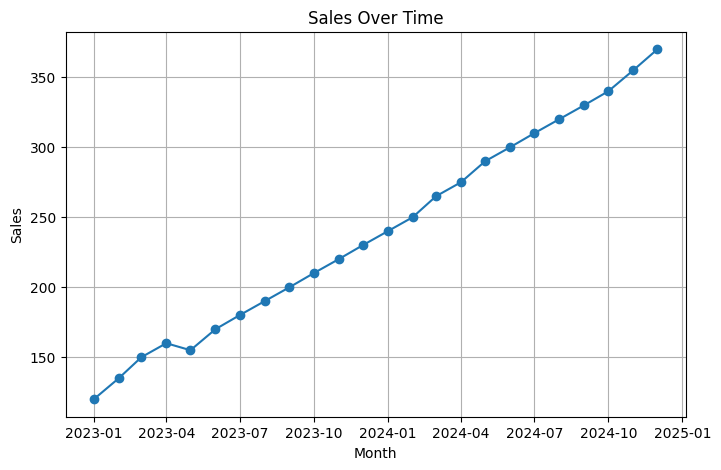

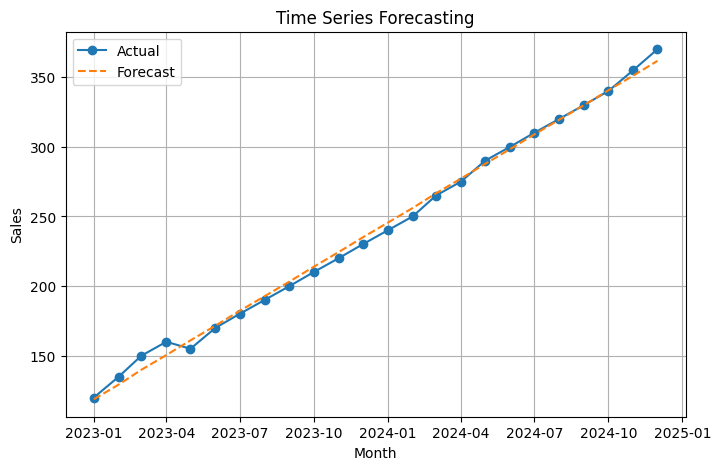


--- Future Forecast ---
Month +1: 372.19
Month +2: 382.75
Month +3: 393.31
Month +4: 403.87
Month +5: 414.43
Month +6: 424.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("time_series.csv")

df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')

# Create time index
df['TimeIndex'] = np.arange(len(df))

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(8,5))
plt.plot(df['Month'], df['Sales'], marker='o')
plt.title("Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

# =========================
# MODEL (Linear Trend Forecasting)
# =========================
X = df[['TimeIndex']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

df['Forecast'] = model.predict(X)

# =========================
# PLOT ACTUAL VS FORECAST
# =========================
plt.figure(figsize=(8,5))
plt.plot(df['Month'], df['Sales'], label="Actual", marker='o')
plt.plot(df['Month'], df['Forecast'], label="Forecast", linestyle='--')
plt.title("Time Series Forecasting")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

# =========================
# FUTURE PREDICTION
# =========================
future_index = np.arange(len(df), len(df)+6).reshape(-1,1)
future_sales = model.predict(future_index)

print("\n--- Future Forecast ---")
for i, val in enumerate(future_sales, 1):
    print(f"Month +{i}: {round(val,2)}")